In [1]:
from google.colab import files
uploaded = files.upload()

Saving kc_house_data.csv to kc_house_data.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('kc_house_data.csv')  # use the exact filename
print("Shape:", df.shape)
df.head()

Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
print(df.isnull().sum())
print(df.dtypes)

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


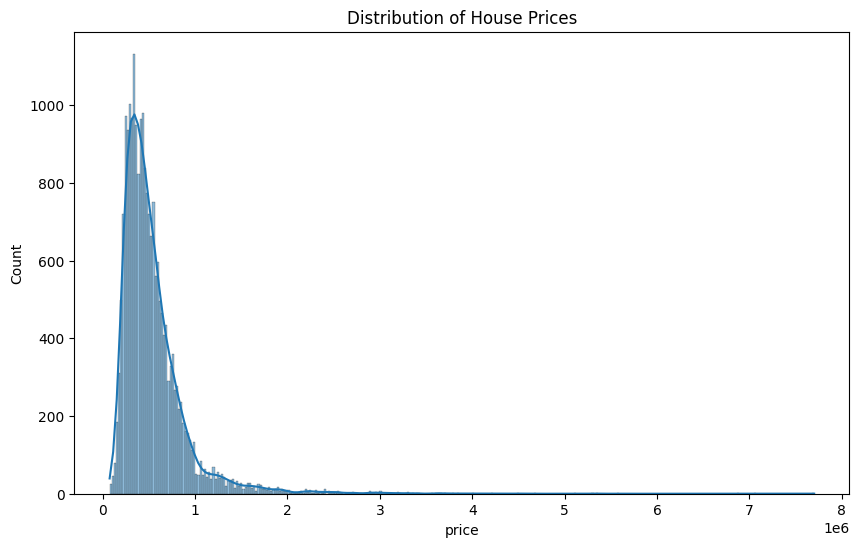

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.show()

In [6]:
correlation = df.corr(numeric_only=True)['price'].sort_values(ascending=False)
print(correlation)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64


Observation:
The features most correlated with price are 'sqft_living' (0.70), 'grade' (0.67), and 'sqft_above' (0.60). These will be key predictors in the model. Features like 'sqft_living15' and 'bathrooms' also show moderate correlation.

In [7]:
# Select top features
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view']
X = df[features]
y = df['price']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (17290, 6)
Test set size: (4323, 6)


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.5791190209921735
RMSE: 252244.7277107101


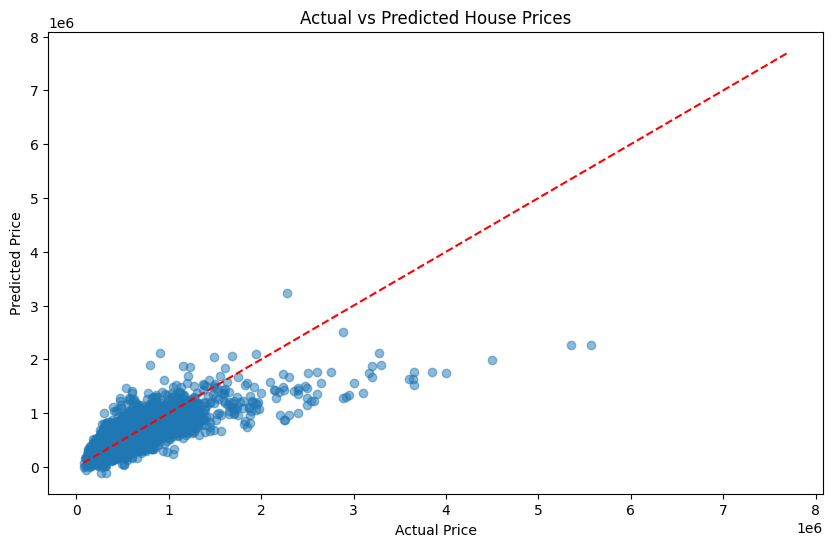

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

Observation:
The scatter plot shows that predictions follow the general trend of actual prices. However, the model tends to underestimate very high-priced houses (> $1.5M), indicating room for improvement with more complex models or additional features.

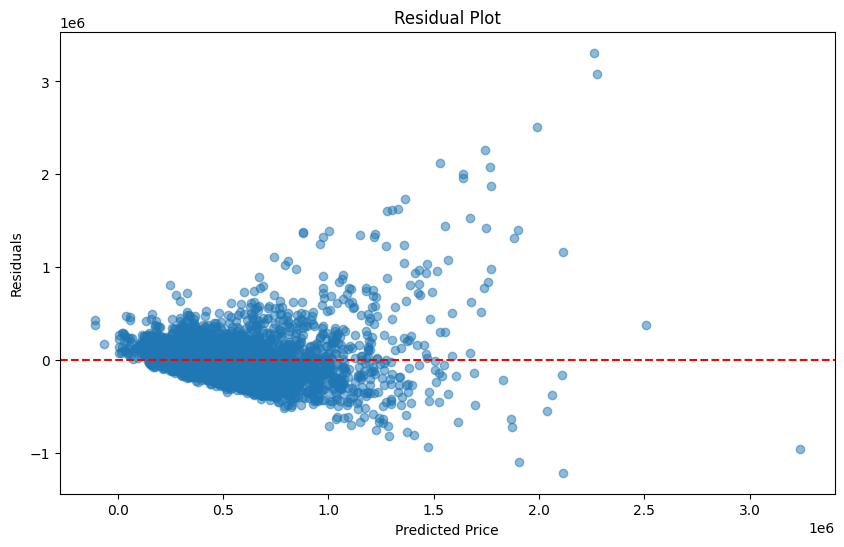

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

Observation:
The residuals are randomly scattered around zero, suggesting that the linear regression model assumptions are reasonably satisfied. However, there is some heteroscedasticity (increasing variance with higher predicted prices), which is common in housing data.

In [12]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print("Top features increasing price:")
print(coeff_df.head())

print("\nTop features decreasing price:")
print(coeff_df.tail())

Top features increasing price:
         Feature    Coefficient
1          grade  100690.079930
5           view   91050.376853
0    sqft_living     208.654870
3  sqft_living15       3.618521
2     sqft_above     -43.568966

Top features decreasing price:
         Feature   Coefficient
5           view  91050.376853
0    sqft_living    208.654870
3  sqft_living15      3.618521
2     sqft_above    -43.568966
4      bathrooms -25867.820706



Observation:
'sqft_living' has the highest positive coefficient, indicating it contributes most to increasing house prices. 'grade' and 'view' also have strong positive effects. However, 'sqft_above' and 'bathrooms' show negative coefficients, suggesting that, when holding other features constant, larger above-ground living area and more bathrooms are associated with lower prices — possibly due to multicollinearity with 'sqft_living'.

In [13]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print("Ridge R²:", r2_score(y_test, ridge.predict(X_test)))

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
print("Lasso R²:", r2_score(y_test, lasso.predict(X_test)))

Ridge R²: 0.5791173751846067
Lasso R²: 0.5791190162545619


Observation:
Ridge and Lasso produced R² scores of 0.579 and 0.579, respectively — nearly identical to the linear regression model (0.579). Regularization did not significantly improve or harm performance, suggesting that multicollinearity is not a major issue with the selected features.